# Clustering 

The **objective** of clustering is to group the observations of (n) individuals based on their values across multiple variables.

Remember:

- A variable is a measurable characteristic or property of the individuals.
An individual is one observation, described by the values of all the variables measured for it.

- For example, if we are studying weather conditions, an individual could be one day, while the variables could be temperature, precipitation, wind speed, and atmospheric pressure.

Clustering aims to identify groups of individuals that are similar to each other based on these variables. Although multiple clustering algorithms exist, they generally require us to answer two fundamental questions:

1. How do we measure **dissimilarity** between individuals?

2. How do we evaluate the **quality of a group** of individuals?

## 01. What does similar or dissimilar mean?

Lets import some libraries that we will need for the rest of the notebook

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

We are going to generate a random dataset consisting of 20 individuals, for which two variables have been measured.

The values of both variables are randomly sampled from a normal distribution with a mean of 0 and a standard deviation of 1.

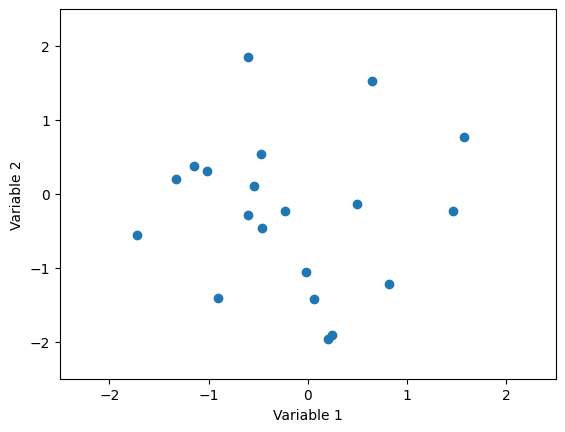

In [16]:
np.random.seed(42)

X = np.random.normal(
    loc=[0, 0],
    scale=[1, 1],
    size=(20, 2)
)

plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")

plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)

plt.show()

We can now ask a fundamental question: how similar are two individuals? One simple way to measure dissimilarity is to calculate the distance between them. We typically use the Euclidean distance between two individuals (i) and (j), considering (p) variables, is defined as:
$$
\sqrt{
\sum_{k=1}^{p}
\left(x_{ik}-x_{jk}\right)^2
}
]
$$
For our case, where we have two variables, this becomes:
$$
\sqrt{
(x_{i1}-x_{j1})^2
+
(x_{i2}-x_{j2})^2
}
]
$$
The Euclidean distance corresponds to the straight-line distance between two points.

A smaller distance means that two individuals are more similar, while a larger distance means that they are more dissimilar. 

Let's select one individual and calculate its distance to the other individuals.

In [6]:
individual_s = X[0]
print('Individual sample:', individual_s)

distances = np.sqrt(
    (X[:, 0] - individual_s[0])**2 +
    (X[:, 1] - individual_s[1])**2
) 

Individual sample: [ 0.49671415 -0.1382643 ]


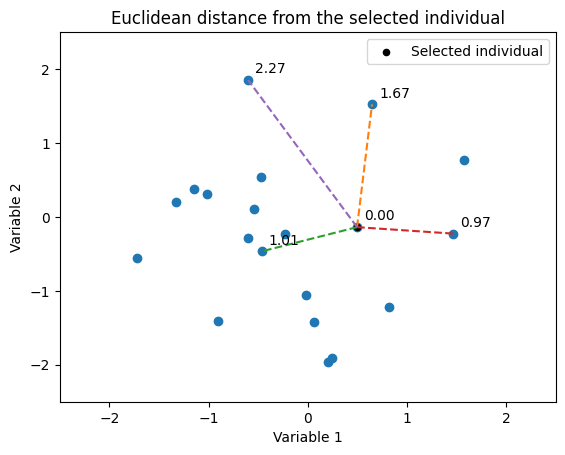

In [15]:
fig, ax = plt.subplots()

ax.scatter(X[:, 0], X[:, 1])
# Highlight the selected individual
ax.scatter(
    X[0, 0],
    X[0, 1],
    s=20,
    label="Selected individual",
    color='k'
)

# Show distances to a few individuals
for i in [0, 1, 5, 10, 15]:
    ax.plot(
        [X[0, 0], X[i, 0]],
        [X[0, 1], X[i, 1]],
        linestyle="--"
    )
    
    ax.annotate(
        f"{distances[i]:.2f}",
        (X[i, 0], X[i, 1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.set_xlabel("Variable 1")
ax.set_ylabel("Variable 2")
ax.set_title("Euclidean distance from the selected individual")
ax.legend()

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)

plt.show()

The Euclidean distance works well and is intuitive when variables have similar scales. However, if variables are measured on very different scales, the distance can be dominated by the variable with the largest scale.

In this case, we can standardize the variables before calculating distances, or use a distance metric that accounts for the scale and correlation between variables, such as the Mahalanobis distance.

However, the choice of scaling is ultimately a modelling decision. If we consider one variable to be more important than another, we can deliberately give it a larger weight in the distance calculation.

This becomes particularly relevant when clustering Principal Components (PCs). The variance of each PC is related to the amount of variance it explains in the original dataset. Standardizing the PCs to unit variance would remove these differences and give all PCs equal weight. Therefore, whether or not to standardize the PCs depends on what we want the clustering to represent.

In [25]:
np.random.seed(42)

X = np.column_stack([
    np.random.normal(0, 1, 10000),
    np.random.normal(0, 10, 10000)
])

In [26]:
point = X[0]

distances = np.sqrt(
    (X[:, 0] - point[0])**2 +
    (X[:, 1] - point[1])**2
)

In [27]:
X_standardized = (X - X.mean(axis=0)) / X.std(axis=0)

point = X_standardized[0]

distances_standardized = np.sqrt(
    (X_standardized[:, 0] - point[0])**2 +
    (X_standardized[:, 1] - point[1])**2
)

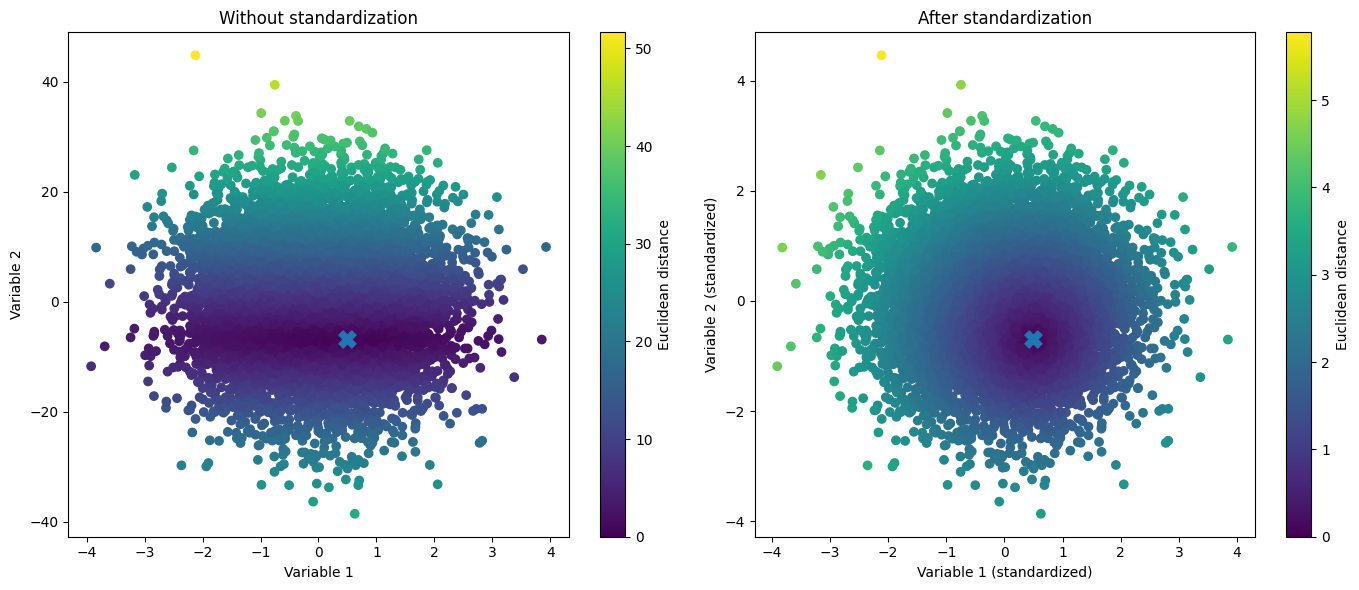

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --------------------------------------------------
# Original data
# --------------------------------------------------

scatter = axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=distances,
    cmap="viridis"
)

axes[0].scatter(
    X[0, 0],
    X[0, 1],
    marker="X",
    s=150
)

axes[0].set_xlabel("Variable 1")
axes[0].set_ylabel("Variable 2")
axes[0].set_title("Without standardization")

fig.colorbar(
    scatter,
    ax=axes[0],
    label="Euclidean distance"
)


# --------------------------------------------------
# Standardized data
# --------------------------------------------------

scatter = axes[1].scatter(
    X_standardized[:, 0],
    X_standardized[:, 1],
    c=distances_standardized,
    cmap="viridis"
)

axes[1].scatter(
    X_standardized[0, 0],
    X_standardized[0, 1],
    marker="X",
    s=150
)

axes[1].set_xlabel("Variable 1 (standardized)")
axes[1].set_ylabel("Variable 2 (standardized)")
axes[1].set_title("After standardization")

fig.colorbar(
    scatter,
    ax=axes[1],
    label="Euclidean distance"
)

plt.tight_layout()
plt.show()